In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df=pd.read_csv('/content/social_media_addiction_dataset (1).csv')
df.head()

,daily_screen_time,app_opens,sleep_hours,stress_level,study_interruptions,night_usage,addiction_level
0,5.4,67,3.8,1,2,No,Moderate
1,4.3,10,6.9,2,7,No,Low
2,7.0,48,5.4,9,3,No,Moderate
3,12.0,16,6.7,2,0,No,Low
4,8.8,25,6.0,3,15,No,Moderate


In [4]:
print(df.columns)

Index(['daily_screen_time', 'app_opens', 'sleep_hours', 'stress_level',
       'study_interruptions', 'night_usage', 'addiction_level'],
      dtype='object')


In [6]:
X = df.drop('addiction_level', axis=1)
y = df['addiction_level']

In [7]:
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
X = pd.get_dummies(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
model = RandomForestClassifier()

In [11]:
model = RandomForestClassifier(n_estimators=100,criterion='gini',max_depth=10,random_state=42)

In [12]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.915


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91        29
           1       0.92      0.50      0.65        22
           2       0.91      0.98      0.94       149

    accuracy                           0.92       200
   macro avg       0.92      0.79      0.83       200
weighted avg       0.92      0.92      0.91       200



In [16]:
print(confusion_matrix(y_test, y_pred))

[[ 26   0   3]
 [  0  11  11]
 [  2   1 146]]


In [17]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

               Feature  Importance
1            app_opens    0.218573
2          sleep_hours    0.214170
0    daily_screen_time    0.188548
3         stress_level    0.174481
4  study_interruptions    0.151197
6      night_usage_Yes    0.026747
5       night_usage_No    0.026284


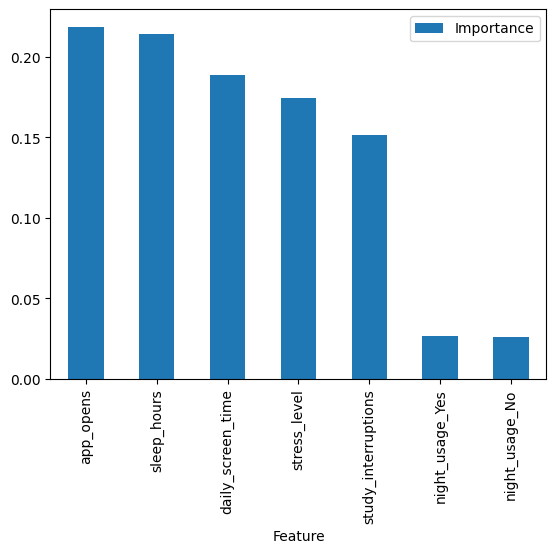

In [18]:
import matplotlib.pyplot as plt
feature_importance.head(10).plot(x='Feature',y='Importance',kind='bar')
plt.show()

In [19]:
import joblib

In [21]:
joblib.dump(model, 'random_forest_own.joblib')

['random_forest_own.joblib']

In [22]:
joblib.dump(model, 'random_forest_own.joblib')

['random_forest_own.joblib']

In [23]:
loaded_model = joblib.load('random_forest_own.joblib')

In [24]:
model = RandomForestClassifier(n_estimators=200,max_depth=15,random_state=42)